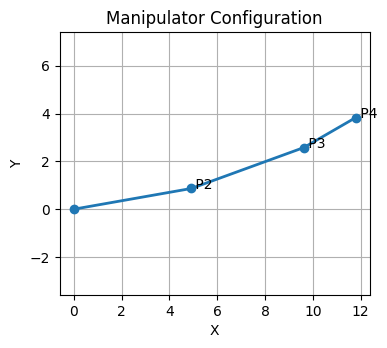

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import ttk
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

# -------- COMPUTE FUNCTION --------
def compute():

    # Clear previous plot
    for widget in plot_frame.winfo_children():
        widget.destroy()

    theta_deg1 = float(entry1.get())
    theta_deg2 = float(entry2.get())
    theta_deg3 = float(entry3.get())

    theta1 = np.deg2rad(theta_deg1)
    theta2 = np.deg2rad(theta_deg2)
    theta3 = np.deg2rad(theta_deg3)

    # Link lengths
    l1 = 5
    l2 = 5
    l3 = 2.5

    # Transformation matrices
    T01 = np.array([
        [np.cos(theta1), -np.sin(theta1), 0, 0],
        [np.sin(theta1),  np.cos(theta1), 0, 0],
        [0,0,1,0],
        [0,0,0,1]
    ])

    T12 = np.array([
        [np.cos(theta2), -np.sin(theta2), 0, l1],
        [np.sin(theta2),  np.cos(theta2), 0, 0],
        [0,0,1,0],
        [0,0,0,1]
    ])

    T23 = np.array([
        [np.cos(theta3), -np.sin(theta3), 0, l2],
        [np.sin(theta3),  np.cos(theta3), 0, 0],
        [0,0,1,0],
        [0,0,0,1]
    ])

    T34 = np.array([
        [1,0,0,l3],
        [0,1,0,0],
        [0,0,1,0],
        [0,0,0,1]
    ])

    # Global transformations
    T02 = T01 @ T12
    T03 = T02 @ T23
    T04 = T03 @ T34

    # Positions
    P0 = np.array([[0],[0],[0]])
    P1 = T01[:3,3].reshape(3,1)
    P2 = T02[:3,3].reshape(3,1)
    P3 = T03[:3,3].reshape(3,1)
    P4 = T04[:3,3].reshape(3,1)

    # -------- ORIENTATION --------
    # Extract orientation (rotation about Z-axis)
    R = T04[:3,:3]
    phi = np.arctan2(R[1,0], R[0,0])   # yaw angle
    phi_deg = np.rad2deg(phi)

    # Display results
    result_text.set(
        f"P1 = {P1.flatten()}\n"
        f"P2 = {P2.flatten()}\n"
        f"P3 = {P3.flatten()}\n"
        f"P4 (Tip) = {P4.flatten()}\n\n"
        f"Final Orientation (deg) = {phi_deg:.2f}"
    )

    # -------- PLOT --------
    x = [0, P2[0,0], P3[0,0], P4[0,0]]
    y = [0, P2[1,0], P3[1,0], P4[1,0]]

    fig, ax = plt.subplots(figsize=(4,4))
    ax.plot(x, y, '-o', linewidth=2)

    ax.text(P2[0,0], P2[1,0], ' P2')
    ax.text(P3[0,0], P3[1,0], ' P3')
    ax.text(P4[0,0], P4[1,0], ' P4')

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title("Manipulator Configuration")
    ax.grid(True)
    ax.axis('equal')

    # Embed plot into Tkinter
    canvas = FigureCanvasTkAgg(fig, master=plot_frame)
    canvas.draw()
    canvas.get_tk_widget().pack()


# -------- GUI WINDOW --------
root = tk.Tk()
root.title("3-Link Manipulator Interface")
root.geometry("500x600")

ttk.Label(root, text="Theta 1 (degrees)").pack()
entry1 = ttk.Entry(root)
entry1.pack()

ttk.Label(root, text="Theta 2 (degrees)").pack()
entry2 = ttk.Entry(root)
entry2.pack()

ttk.Label(root, text="Theta 3 (degrees)").pack()
entry3 = ttk.Entry(root)
entry3.pack()

ttk.Button(root, text="Compute & Plot", command=compute).pack(pady=10)

result_text = tk.StringVar()
ttk.Label(root, textvariable=result_text).pack()

# Frame for plot
plot_frame = ttk.Frame(root)
plot_frame.pack(fill="both", expand=True)

root.mainloop()